In [2]:
import sys
import os

sys.path.append(os.path.abspath('../src'))


import visuals as vs

In [3]:
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualization code visuals.py
import visuals as vs
from visuals import distribution
# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv('../data/raw/census.csv')


# Success - Display the first record
display(data.head(n=1))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K


## 1. Data Exploration and Statistical Summary

In this section, we conduct a preliminary investigation of the dataset to understand the distribution of our target variable, `income`. This helps determine the balance of our classes and provides a baseline for evaluating model performance.

- **Objective:** Calculate the total number of individuals and the percentage of those earning more than $50,000.

In [4]:

n_records = len(data)

n_greater_50k = len(data[data['income'] == '>50K'])


n_at_most_50k = len(data[data['income'] == '<=50K'])

greater_percent = (n_greater_50k / n_records) * 100

In [5]:
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {:.2f}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 24.78%


### Key Insights from Exploration:
- The dataset contains **45,222** records.
- **24.78%** of individuals earn more than $50,000, while the majority (**75.22%**) earn $50,000 or less.
- **Conclusion:** The dataset is imbalanced. A naive model predicting everyone earns $\le$50K would have high accuracy but zero predictive power for donors.

h:\projects\CharityML Donor Prediction\src\visuals.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


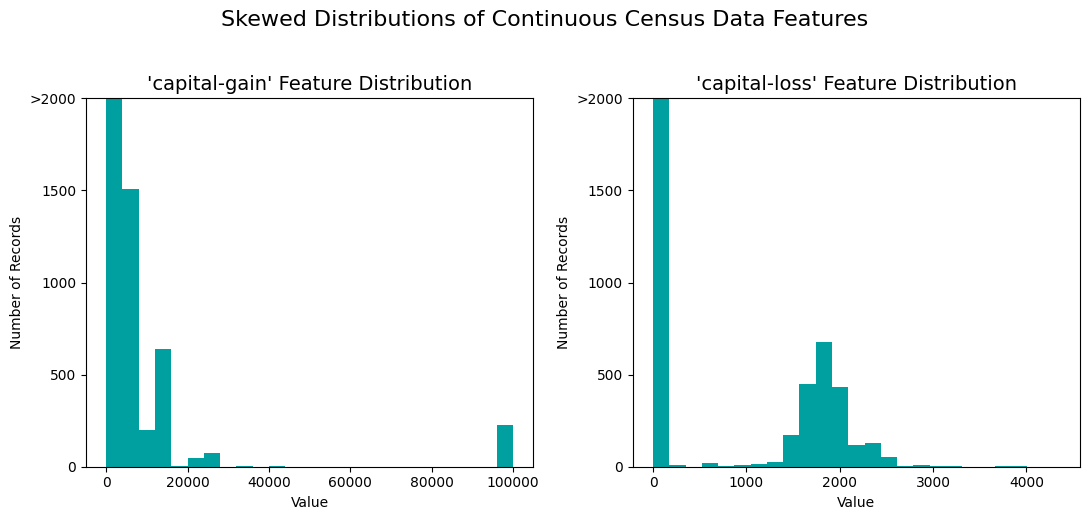

In [6]:

income_raw = data['income']
features_raw = data.drop('income', axis = 1)


import visuals as vs

vs.distribution(data)

## 2. Feature Analysis: Handling Skewness

Visualizing the distributions of `'capital-gain'` and `'capital-loss'` reveals highly skewed data. Most values are clustered at zero, with a long tail of extreme outliers reaching $100,000. 

### Why Log Transformation?
Learning algorithms can be sensitive to such wide ranges. By applying a **Logarithmic Transformation**, we compress the range from [0, 100,000] to approximately [0, 12], making the distribution more "normal" and preventing outliers from dominating the model's weight updates.

h:\projects\CharityML Donor Prediction\src\visuals.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


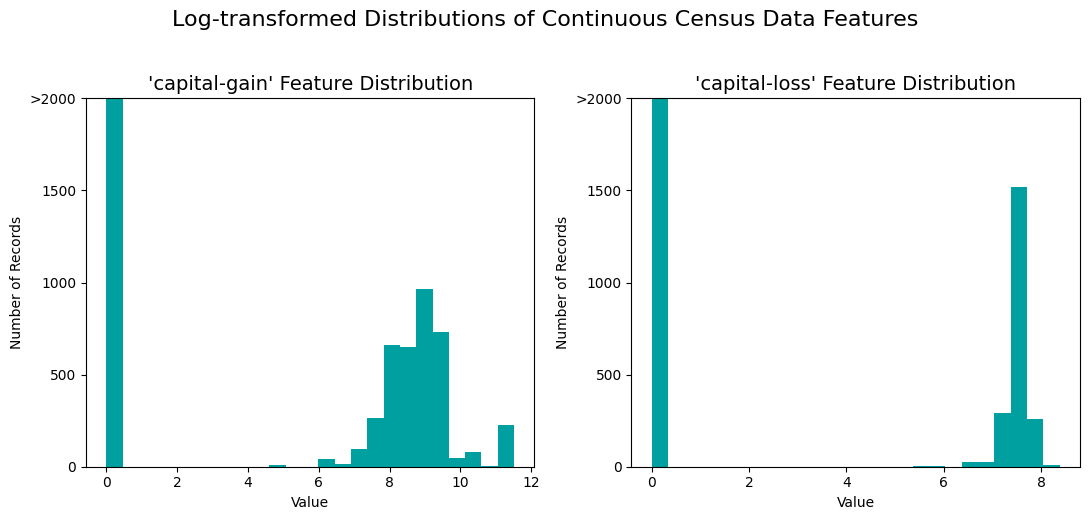

In [7]:
import numpy as np


skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = data)
features_log_transformed[skewed] = data[skewed].apply(lambda x: np.log(x + 1))

vs.distribution(features_log_transformed, transformed = True)


## 3. Data Scaling and Normalization

Numerical features like `age` and `hours-per-week` have different scales. To ensure each feature is treated equally by supervised learners, we apply **MinMaxScaler**. This scales all numerical features into the range [0, 1].

- **Impact:** Normalization preserves the shape of the distribution while ensuring no single feature dominates others due to its magnitude.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba,<=50K


## 4. Data Preprocessing: Categorical Encoding

Machine learning models require numerical input. We use **One-Hot Encoding** to convert categorical variables (like `workclass` and `education_level`) into multiple binary columns. 

- **Target Encoding:** The target label `income` is mapped to numerical values: `0` for `<=50K` and `1` for `>50K`.
- **Result:** After encoding, the feature set expanded from 13 original features to **103 total features**.

In [9]:
# One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

# Encode the 'income_raw' data to numerical values (0 or 1)
income = data['income'].map({'>50K': 1, '<=50K': 0})

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print(f"{len(encoded)} total features after one-hot encoding.")

105 total features after one-hot encoding.


In [10]:
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


In [11]:

TP = np.sum(income) # True Positives
FP = income.count() - TP # False Positives (كل الـ 0 تم توقعهم خطأ كـ 1)
TN = 0 # No True Negatives
FN = 0 # No False Negatives


accuracy = TP / (TP + FP)
recall = TP / (TP + FN)
precision = TP / (TP + FP)


beta = 0.5
fscore = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)


print(f"Naive Predictor: [Accuracy score: {accuracy:.4f}, F-score: {fscore:.4f}]")

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `'accuracy'` and `'fscore'` to be used later.

** Please note ** that the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

** HINT: ** 

* When we have a model that always predicts '1' (i.e. the individual makes more than 50k) then our model will have no True Negatives(TN) or False Negatives(FN) as we are not making any negative('0' value) predictions. Therefore our Accuracy in this case becomes the same as our Precision(True Positives/(True Positives + False Positives)) as every prediction that we have made with value '1' that should have '0' becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score(True Positives/(True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

**ANSWER**:In a naive case where we always predict an individual earns more than $50,000 (Income = 1), the model’s performance metrics are calculated as follows:

Accuracy: Approximately 0.2478. Since the majority of the dataset consists of individuals earning 
≤50K
, always predicting the positive class leads to a low accuracy. In this specific scenario, Accuracy is equal to Precision because the total number of records becomes our denominator.

Precision: Approximately 0.2478. This is low because we have a high number of False Positives (predicting 
>50K
 for everyone, including those who actually earn 
≤50K
).

Recall: Exactly 1.0. Since we predict every single person earns 
>50K
, we successfully capture all true positives in the dataset, resulting in zero False Negatives.

F-score (
β=0.5
): Approximately 0.2917. We use an F-beta score with 
β=0.5
 to place more importance on Precision than Recall. CharityML wants to minimize "False Positives" to avoid wasting resources on outreach to individuals who are unlikely to donate.

Conclusion:
This naive benchmark shows that a model with no "intelligence" performs poorly, especially regarding precision. Our goal for the upcoming supervised learning models is to significantly improve the F-score beyond 0.2917 and the Accuracy beyond 0.2478.

In [12]:
# استدعاء الـ Functions اللي لسه كاتبينها
import sys
import os
sys.path.append(os.path.abspath('../src')) # عشان يشوف فولدر src
from data_prep import clean_and_preprocess, save_processed_data

# تنفيذ التنظيف
features_final, income_final = clean_and_preprocess(data)

# تحديد مسار الحفظ (فولدر data/processed)
output_path = "../data/processed/census_cleaned.csv"

# إنشاء الفولدر لو مش موجود
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# حفظ الملف
save_processed_data(features_final, income_final, output_path)

✅ Successfully saved processed data to: ../data/processed/census_cleaned.csv
